In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

LOAD AND INSPECT DATA

In [240]:
df = pd.read_csv("data/automobile-price-analysis-in-the-nigerian-used-car-market.csv")
df.head(50)

,title,make,model,year,condition,transmission,price
0,Mercedes-Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,foreign used,automatic,"₦ 29,109,375"
1,Toyota Camry 2013,Toyota,Camry,2013.0,local used,automatic,"₦ 8,650,000"
2,Mercedes-Benz C43 4Matic Sedan AWD (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,local used,automatic,"₦ 19,500,000"
3,Mercedes-Benz E350 Base 4Matic Wagon AWD (3.5L...,Mercedes-Benz,E350 Base,2015.0,foreign used,automatic,"₦ 21,500,000"
4,Toyota Land Cruiser 3.5 Petrol 4WD 2022 Black,Toyota,Land Cruiser,2022.0,foreign used,automatic,"₦ 378,000,000"
5,Toyota Camry LE 4dr Sedan (2.4L 4cyl 4A) 2004,Toyota,Camry LE,2004.0,foreign used,automatic,"₦ 7,000,000"
6,Mercedes-Benz G-Class 2004 Black,Mercedes-Benz,G-Class,2004.0,local used,automatic,"₦ 31,500,000"
7,Lexus LX 600 2024 Gray,Lexus,LX 600,2024.0,local used,automatic,"₦ 235,000,000"
8,Lexus RX 2014 White,Lexus,RX,2014.0,foreign used,automatic,"₦ 22,200,000"
9,Toyota RAV4 2004 White,Toyota,RAV4,2004.0,local used,automatic,"₦ 4,500,000"


In [276]:
df['Condition'].unique()

<ArrowStringArray>
['foreign used', 'local used', 'brand new']
Length: 3, dtype: str

In [241]:
#check the info of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         2000 non-null   str    
 1   make          1992 non-null   str    
 2   model         1992 non-null   str    
 3   year          1992 non-null   float64
 4   condition     2000 non-null   str    
 5   transmission  1996 non-null   str    
 6   price         2000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 271.3 KB


In [242]:
#get the dataset shape
df.shape

(2000, 7)

In [243]:
#get the dataset colunms
df.columns

Index(['title', 'make', 'model', 'year', 'condition', 'transmission', 'price'], dtype='str')

In [244]:
#check missing value
df.isnull().sum()

title           0
make            8
model           8
year            8
condition       0
transmission    4
price           0
dtype: int64

In [245]:
#inspect unique values in columns
print(df['title'].unique())
print(df['make'].unique())
print(df['model'].unique())
print(df['year'].unique())
print(df['condition'].unique())
print(df['transmission'].unique())
print(df['price'].unique())

<ArrowStringArray>
[                                 'Mercedes-Benz M Class 2015 Silver',
                                                  'Toyota Camry 2013',
       'Mercedes-Benz C43 4Matic Sedan AWD (3.0L V6 9AM) 2017 Silver',
 'Mercedes-Benz E350 Base 4Matic Wagon AWD (3.5L 6cyl 7A) 2015 White',
                      'Toyota Land Cruiser 3.5 Petrol 4WD 2022 Black',
                      'Toyota Camry LE 4dr Sedan (2.4L 4cyl 4A) 2004',
                                   'Mercedes-Benz G-Class 2004 Black',
                                             'Lexus LX 600 2024 Gray',
                                                'Lexus RX 2014 White',
                                             'Toyota RAV4 2004 White',
 ...
                                           'Hyundai Sonata 2015 Gray',
                                  'Honda Accord Crosstour 2013 White',
                              'Lexus GX 470 Sport Utility 2005 Black',
      'Mercedes-Benz M Class ML350 4dr SUV (3.5L 6cyl

In [246]:
#Standardize categorical columns
df.rename(columns={
    "title": "Title",
    "make": "Make",
    "model": "Model",
    "year": "Year",
    "transmission": "Transmission",
    "condition": "Condition",
    "price": "Price"
    
        
}, inplace=True)
df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes-Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,foreign used,automatic,"₦ 29,109,375"
1,Toyota Camry 2013,Toyota,Camry,2013.0,local used,automatic,"₦ 8,650,000"
2,Mercedes-Benz C43 4Matic Sedan AWD (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,local used,automatic,"₦ 19,500,000"
3,Mercedes-Benz E350 Base 4Matic Wagon AWD (3.5L...,Mercedes-Benz,E350 Base,2015.0,foreign used,automatic,"₦ 21,500,000"
4,Toyota Land Cruiser 3.5 Petrol 4WD 2022 Black,Toyota,Land Cruiser,2022.0,foreign used,automatic,"₦ 378,000,000"
...,...,...,...,...,...,...,...
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,local used,automatic,"₦ 4,400,000"
1996,Toyota Highlander XSE AWD 2024 Black,Toyota,Highlander XSE,2024.0,foreign used,automatic,"₦ 80,000,000"
1997,Toyota Corolla S 4dr Sedan (1.8L 4cyl 4A) 2013...,Toyota,Corolla S,2013.0,local used,automatic,"₦ 6,300,000"
1998,Mercedes-Benz C300 2016 White,Mercedes-Benz,C300,2016.0,foreign used,automatic,"₦ 21,000,000"


In [247]:
#clean incosistence values on full_name
df['Title'] = (
    df['Title']
    .str.strip()
    .str.title()
    .str.replace(r"[\s-]+", " ", regex=True)
)
df['Title'].to_list()

['Mercedes Benz M Class 2015 Silver',
 'Toyota Camry 2013',
 'Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9Am) 2017 Silver',
 'Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L 6Cyl 7A) 2015 White',
 'Toyota Land Cruiser 3.5 Petrol 4Wd 2022 Black',
 'Toyota Camry Le 4Dr Sedan (2.4L 4Cyl 4A) 2004',
 'Mercedes Benz G Class 2004 Black',
 'Lexus Lx 600 2024 Gray',
 'Lexus Rx 2014 White',
 'Toyota Rav4 2004 White',
 'Toyota Venza 2010 Black',
 'Bmw X1 Xdrive28I Awd 2018 White',
 'Mercedes Benz M Class Ml350 4Matic 4Dr Suv Awd (3.5L 6Cyl 7A) 2014 Silver',
 'Toyota Camry 2002 Silver',
 'Toyota Carina E 1.6 Wagon 1998 Red',
 'Honda Pilot 2007 Gray',
 'Lexus Is 200T 2016 Gray',
 'Lexus Rx 350 2010 White',
 'Honda Accord 2004 Silver',
 'Toyota Camry 2008 Blue',
 'Honda Accord 2018 Gray',
 'Lexus Rx 350 2011 Gray',
 'Toyota Venza 2014 Silver',
 'Honda Accord 2018 Black',
 'Toyota Hilux 1998 White',
 'Toyota Corolla Le 4Dr Sedan (1.8L 4Cyl 4A) 2013 Black',
 'Toyota Rav4 2015 Gray',
 'Honda Civic 2005

In [248]:
df.describe()

,Year
count,1992.000000
mean,2013.305221
std,6.058580
min,1958.000000
25%,2009.000000
50%,2014.000000
75%,2017.000000
max,2026.000000


In [249]:
df['Price'].describe()

count            2000
unique            608
top       ₦ 6,500,000
freq               35
Name: Price, dtype: object

In [281]:
is_new_mask = df['Make'] == 'New'

df.loc[is_new_mask, 'Make'] = df.loc[is_new_mask, 'Model'].str.split().str[0]
df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,foreign used,automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013.0,local used,automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,local used,automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015.0,foreign used,automatic,21500000
4,Toyota Land Cruiser 3.5 Petrol 4Wd 2022 Black,Toyota,Land Cruiser,2022.0,foreign used,automatic,378000000
...,...,...,...,...,...,...,...
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,local used,automatic,4400000
1996,Toyota Highlander Xse Awd 2024 Black,Toyota,Highlander XSE,2024.0,foreign used,automatic,80000000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013.0,local used,automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016.0,foreign used,automatic,21000000


In [282]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('₦', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,foreign used,automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013.0,local used,automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,local used,automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015.0,foreign used,automatic,21500000
4,Toyota Land Cruiser 3.5 Petrol 4Wd 2022 Black,Toyota,Land Cruiser,2022.0,foreign used,automatic,378000000
...,...,...,...,...,...,...,...
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,local used,automatic,4400000
1996,Toyota Highlander Xse Awd 2024 Black,Toyota,Highlander XSE,2024.0,foreign used,automatic,80000000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013.0,local used,automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016.0,foreign used,automatic,21000000


In [283]:
#exclude an outliers in dataframe

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
Q1
Q3
IQR = Q3 -Q1
IQR

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ( df['Price'] < lower_bound) | ( df['Price'] > upper_bound)

print(outliers.sum())

new_df = df[
    (df['Price'] > lower_bound) & ( df['Price'] < upper_bound)
] 

new_df

234


,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,foreign used,automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013.0,local used,automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,local used,automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015.0,foreign used,automatic,21500000
5,Toyota Camry Le 4Dr Sedan (2.4L 4Cyl 4A) 2004,Toyota,Camry LE,2004.0,foreign used,automatic,7000000
...,...,...,...,...,...,...,...
1994,Toyota Rav4 2.5 Limited 4X4 2011 Red,Toyota,RAV4 2,2011.0,foreign used,automatic,11700000
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,local used,automatic,4400000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013.0,local used,automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016.0,foreign used,automatic,21000000


In [284]:
new_df.dtypes

Title               str
Make                str
Model               str
Year            float64
Condition           str
Transmission        str
Price             int64
dtype: object

In [285]:
new_df.dropna(inplace=True)

new_df.info()
new_df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 1755 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1755 non-null   str    
 1   Make          1755 non-null   str    
 2   Model         1755 non-null   str    
 3   Year          1755 non-null   float64
 4   Condition     1755 non-null   str    
 5   Transmission  1755 non-null   str    
 6   Price         1755 non-null   int64  
dtypes: float64(1), int64(1), str(5)
memory usage: 227.2 KB


Title           0
Make            0
Model           0
Year            0
Condition       0
Transmission    0
Price           0
dtype: int64

In [286]:
new_df['Make'] = new_df['Make'].replace({
    'Mercedes Benz':'Mercedes-Benz',
    'Mercedes Benz.':'Mercedes-Benz',
    'Benz':'Mercedes-Benz'
})
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,foreign used,automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013.0,local used,automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,local used,automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015.0,foreign used,automatic,21500000
5,Toyota Camry Le 4Dr Sedan (2.4L 4Cyl 4A) 2004,Toyota,Camry LE,2004.0,foreign used,automatic,7000000
...,...,...,...,...,...,...,...
1994,Toyota Rav4 2.5 Limited 4X4 2011 Red,Toyota,RAV4 2,2011.0,foreign used,automatic,11700000
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,local used,automatic,4400000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013.0,local used,automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016.0,foreign used,automatic,21000000


In [287]:
new_df['Condition'] = new_df['Condition'].replace({
    "foreign used": "Foreign Used",
    "local used": "Local Used",
    "brand new": "Brand new"
})
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,Foreign Used,automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013.0,Local Used,automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,Local Used,automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015.0,Foreign Used,automatic,21500000
5,Toyota Camry Le 4Dr Sedan (2.4L 4Cyl 4A) 2004,Toyota,Camry LE,2004.0,Foreign Used,automatic,7000000
...,...,...,...,...,...,...,...
1994,Toyota Rav4 2.5 Limited 4X4 2011 Red,Toyota,RAV4 2,2011.0,Foreign Used,automatic,11700000
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,Local Used,automatic,4400000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013.0,Local Used,automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016.0,Foreign Used,automatic,21000000


In [288]:
new_df['Transmission'] = new_df['Transmission'].replace({
    "automatic": "Automatic",
    "manual": "Manual"
    
})
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015.0,Foreign Used,Automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013.0,Local Used,Automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017.0,Local Used,Automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015.0,Foreign Used,Automatic,21500000
5,Toyota Camry Le 4Dr Sedan (2.4L 4Cyl 4A) 2004,Toyota,Camry LE,2004.0,Foreign Used,Automatic,7000000
...,...,...,...,...,...,...,...
1994,Toyota Rav4 2.5 Limited 4X4 2011 Red,Toyota,RAV4 2,2011.0,Foreign Used,Automatic,11700000
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007.0,Local Used,Automatic,4400000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013.0,Local Used,Automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016.0,Foreign Used,Automatic,21000000


In [289]:
new_df['Make'].tail(50)

1944            Honda
1945            Lexus
1946           Toyota
1947            Lexus
1948           Toyota
1949            Lexus
1950            Lexus
1952           Toyota
1953    Mercedes-Benz
1954           Toyota
1955           Toyota
1956    Mercedes-Benz
1957           Toyota
1958            Lexus
1959            Lexus
1960            Lexus
1962           Toyota
1963           Toyota
1965            Lexus
1966           Toyota
1967            Lexus
1968           Toyota
1969            Lexus
1970           Toyota
1971            Lexus
1972           Toyota
1973            Honda
1974            Lexus
1975           Toyota
1976             Ford
1978            Volvo
1979          Hyundai
1980           Toyota
1981              Car
1982            Honda
1983              Car
1984    Mercedes-Benz
1985              BMW
1986             Ford
1987            Acura
1988          Hyundai
1989            Honda
1991            Lexus
1992    Mercedes-Benz
1993            Lexus
1994      

In [290]:
#Convert year to integer
new_df['Year'] = pd.to_numeric(new_df['Year'], errors='coerce')

new_df['Year'].isnull().sum()

np.int64(0)

In [291]:
#Remove rows where the year is clearly invalid (e.g., > 2025 or < 1980).
new_df = new_df[(new_df['Year'] >= 1980) & (new_df['Year'] <= 2025)]

new_df['Year'] = new_df['Year'].astype(int)
new_df

,Title,Make,Model,Year,Condition,Transmission,Price
0,Mercedes Benz M Class 2015 Silver,Mercedes-Benz,M Class,2015,Foreign Used,Automatic,29109375
1,Toyota Camry 2013,Toyota,Camry,2013,Local Used,Automatic,8650000
2,Mercedes Benz C43 4Matic Sedan Awd (3.0L V6 9A...,Mercedes-Benz,C43 4Matic,2017,Local Used,Automatic,19500000
3,Mercedes Benz E350 Base 4Matic Wagon Awd (3.5L...,Mercedes-Benz,E350 Base,2015,Foreign Used,Automatic,21500000
5,Toyota Camry Le 4Dr Sedan (2.4L 4Cyl 4A) 2004,Toyota,Camry LE,2004,Foreign Used,Automatic,7000000
...,...,...,...,...,...,...,...
1994,Toyota Rav4 2.5 Limited 4X4 2011 Red,Toyota,RAV4 2,2011,Foreign Used,Automatic,11700000
1995,Toyota Highlander 2007 Blue,Toyota,Highlander,2007,Local Used,Automatic,4400000
1997,Toyota Corolla S 4Dr Sedan (1.8L 4Cyl 4A) 2013...,Toyota,Corolla S,2013,Local Used,Automatic,6300000
1998,Mercedes Benz C300 2016 White,Mercedes-Benz,C300,2016,Foreign Used,Automatic,21000000


Exploratory Data Analysis (EDA)


1. What are the most common car brands (make)?


Frequency count of each brand.


Visualize with a bar chart.




In [292]:
brand_count = new_df['Make'].value_counts()

print(brand_count.head(10))

Make
Toyota           783
Lexus            274
Mercedes-Benz    235
Honda            160
Hyundai           65
Ford              38
Acura             22
Audi              21
Nissan            18
BMW               16
Name: count, dtype: int64


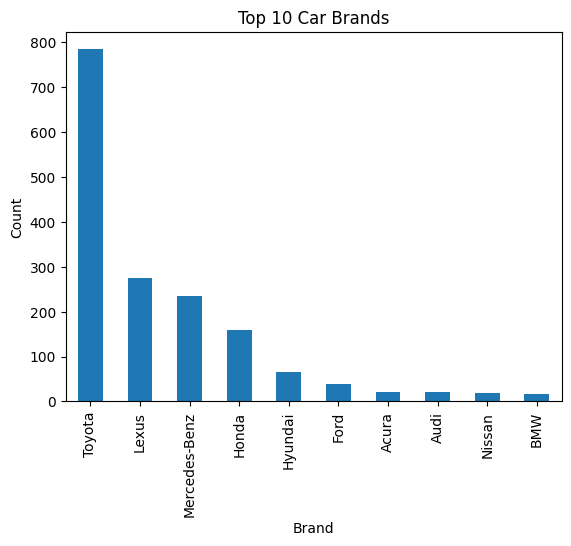

In [293]:
brand_count.head(10).plot(kind='bar')
plt.title('Top 10 Car Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

2. What are the most common models per brand?


For example, which Toyota models appear most frequently?


In [294]:
toyota_models = (
    new_df[new_df['Make']=='Toyota']['Model']
    .value_counts()
)

print(toyota_models.head(10))

Model
Camry                 102
Corolla                51
Highlander             41
Camry LE               38
Land Cruiser           36
Corolla LE             34
RAV4                   29
Highlander Limited     29
Sienna                 28
Camry SE               27
Name: count, dtype: int64


3. What’s the distribution of car years?


Histogram of year shows age distribution of listed cars.


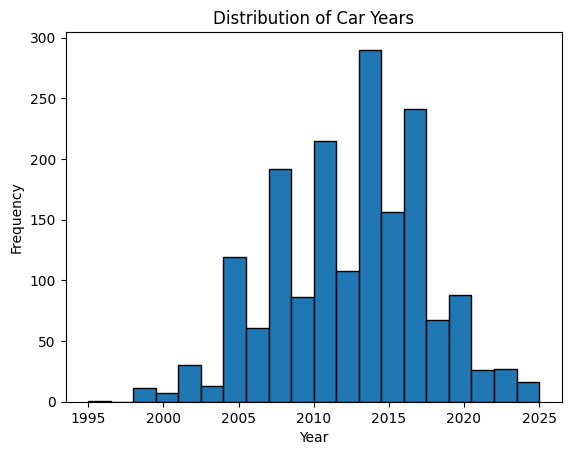

In [295]:
plt.hist(new_df['Year'], bins=20, edgecolor='black')
plt.title('Distribution of Car Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()


4. What is the average price by brand and model?


Compare mean/median price by make and model.


Which brands are the most expensive on average?




In [296]:
avg_brand_price = (
    new_df.groupby('Make')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(avg_brand_price.head(10))


Make
Arcfox      45000000.0
Tesla       42000000.0
Dongfeng    40000000.0
Jeep        39500000.0
Chrysler    36850000.0
Rover       35800000.0
Changan     28000000.0
GMC         27175000.0
Land        25843750.0
Cadillac    25000000.0
Name: Price, dtype: float64


In [297]:
median_brand_price = (
    new_df.groupby('Make')['Price']
    .median()
    .sort_values(ascending=False)
)
print(median_brand_price.head(10))

Make
Arcfox      45000000.0
Tesla       42000000.0
Dongfeng    40000000.0
Jeep        39500000.0
Chrysler    36850000.0
Rover       35800000.0
Land        28000000.0
Changan     28000000.0
GMC         27175000.0
Cadillac    25000000.0
Name: Price, dtype: float64


In [298]:
avg_model_price = (
    new_df.groupby('Model')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(avg_model_price.head(10))

Model
Toyota Hilux           6.090000e+07
Highlander XSE         6.025000e+07
Highlander Platinum    5.900000e+07
Arcfox alphaS5         5.800000e+07
X2                     5.800000e+07
Hilux Revo             5.306667e+07
Hilux Rogue            5.200000e+07
Toyota Starlet         5.200000e+07
RX 350L                5.003333e+07
Wrangler Sport         5.000000e+07
Name: Price, dtype: float64


5. How does car condition affect price?


Compare “Foreign Used” vs “Local Used” prices.


Boxplot for visual insight.


In [299]:
new_df.groupby('Condition')['Price'].mean()

Condition
Brand new       3.705000e+07
Foreign Used    2.274127e+07
Local Used      1.113292e+07
Name: Price, dtype: float64

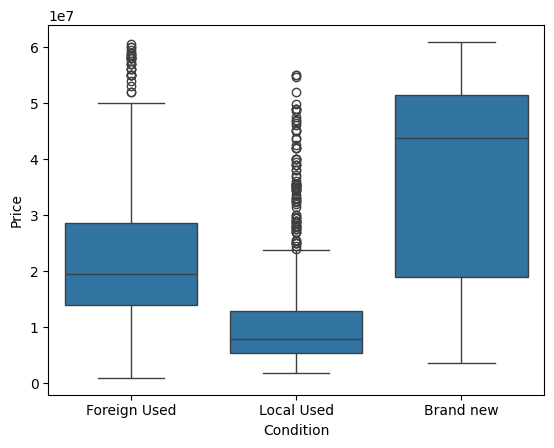

In [300]:
sns.boxplot(
    data=new_df,
    x='Condition',
    y='Price'
)
plt.show()

6. How does transmission type affect price?


Compare “Automatic” vs “Manual”.


Are automatic cars generally pricier?


In [301]:
new_df.groupby('Transmission')['Price'].mean()

Transmission
Automatic    1.699363e+07
Manual       1.002148e+07
Name: Price, dtype: float64

In [302]:
new_df['Transmission'].value_counts()

Transmission
Automatic    1727
Manual         27
Name: count, dtype: int64

7. Are newer cars significantly more expensive?


Scatterplot of year vs price.


Correlation coefficient between year and price.


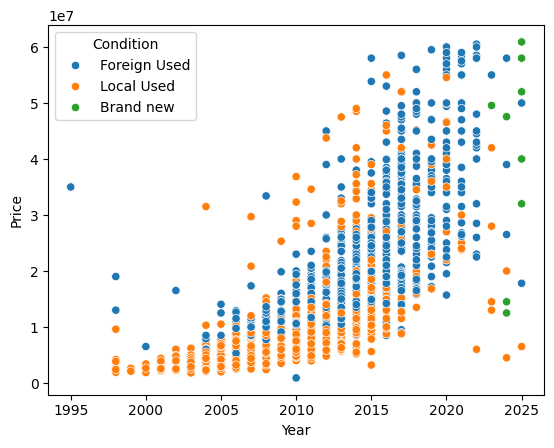

In [303]:
sns.scatterplot(
    data=new_df,
    x='Year',
    y='Price',
    hue='Condition'
)

plt.show()

In [304]:
new_df[['Year','Price']].corr()

,Year,Price
Year,1.000000,0.726293
Price,0.726293,1.000000


In [305]:
new_df.info()

<class 'pandas.DataFrame'>
Index: 1754 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         1754 non-null   str  
 1   Make          1754 non-null   str  
 2   Model         1754 non-null   str  
 3   Year          1754 non-null   int64
 4   Condition     1754 non-null   str  
 5   Transmission  1754 non-null   str  
 6   Price         1754 non-null   int64
dtypes: int64(2), str(5)
memory usage: 227.1 KB


In [306]:
new_df.to_csv("data/automation-analysis-cleaned-dataset.csv", index=False)